# Biosignal Stress Classification — Thesis Overview

**Goal:** classify which phase of a lab stress protocol (Relax / Physical / Cognitive / Emotional stress) a subject is in, using only wrist-worn biosignals (accelerometer, EDA, skin temperature, heart rate, SpO2).

This notebook is the single condensed walkthrough of the project: raw signals → preprocessing → frequency-domain features → statistical features → modeling → conclusions. It re-runs the real pipeline end to end (a few seconds of compute) by calling the same `src/` code the detailed notebooks use, so every number and plot below is reproduced live, not copy-pasted.

The full derivations, exploratory dead ends, and verification steps live in `01_exploration.ipynb` through `05_modeling.ipynb`, alongside this notebook; this notebook deliberately skips those and keeps only the defensible main line.

In [1]:
import sys
from collections import Counter

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from src.preprocessing import (
    assemble_subject_rows,
    filter_signal,
    get_phase_segments,
    get_phase_windows,
    load_and_preprocess_subject,
    load_record,
    subject_paths,
)
from src.features import compute_acc_magnitude, compute_spectrogram, extract_window_features
from src.statistical_features import extract_window_statistical_features

RANDOM_STATE = 42
CLASS_ORDER = ['Relax', 'PhysicalStress', 'CognitiveStress', 'EmotionalStress']
WINDOW_SECONDS, STEP_SECONDS = 60, 30

## 1. Dataset & protocol

**Source:** Non-EEG Dataset for Assessment of Neurological Status (PhysioNet, v1.0.0) — 20 healthy subjects wearing an Empatica E4 wrist sensor while going through a fixed lab stress protocol.

Each subject has **two** separate WFDB records:

| Record | Channels | Sampling rate | Phase annotations |
|---|---|---|---|
| `AccTempEDA` | ax, ay, az (accelerometer), temp, EDA | 8 Hz | yes |
| `SpO2HR` | SpO2, hr | 1 Hz | no — borrowed from `AccTempEDA` |

**Fixed phase order** (identical for every subject — this fact matters later):

| # | Phase | Duration | Notes |
|---|---|---|---|
| 1 | Relax | 5 min | Baseline |
| 2 | PhysicalStress | ~5.5 min | Treadmill, 1→3 mph |
| 3 | Relax | 5 min | |
| 4 | EmotionalStress (mini) | ~40 s | Anticipation only — too short to window, dropped |
| 5 | CognitiveStress | ~6 min | Serial-7s + Stroop test |
| 6 | Relax | 5 min | |
| 7 | EmotionalStress | ~6 min | Horror clip |
| 8 | Relax | 5 min | |

In [2]:
eda_path, hr_path = subject_paths(1)
record_eda = load_record(eda_path, annotation_extension='atr')
record_hr = load_record(hr_path, annotation_extension=None)

for name, rec in [('AccTempEDA', record_eda), ('SpO2HR', record_hr)]:
    dur = rec['signal'].shape[0] / rec['sampling_frequency'] / 60
    print(f"{name:12s} channels={rec['signal_names']}  fs={rec['sampling_frequency']} Hz  duration={dur:.1f} min")

print()
segments = get_phase_segments(record_eda)
print(f"{'Phase':<18}{'Duration (s)':>14}")
for seg in segments:
    print(f"{seg['label']:<18}{len(seg['signal']) / record_eda['sampling_frequency']:>14.1f}")

AccTempEDA   channels=['ax', 'ay', 'az', 'temp', 'EDA']  fs=8 Hz  duration=38.2 min
SpO2HR       channels=['SpO2', 'hr']  fs=1 Hz  duration=38.3 min

Phase               Duration (s)
Relax                      300.0
PhysicalStress             328.1
Relax                      300.1
EmotionalStress             40.1
CognitiveStress            364.1
Relax                      300.1
EmotionalStress            360.1
Relax                      300.0


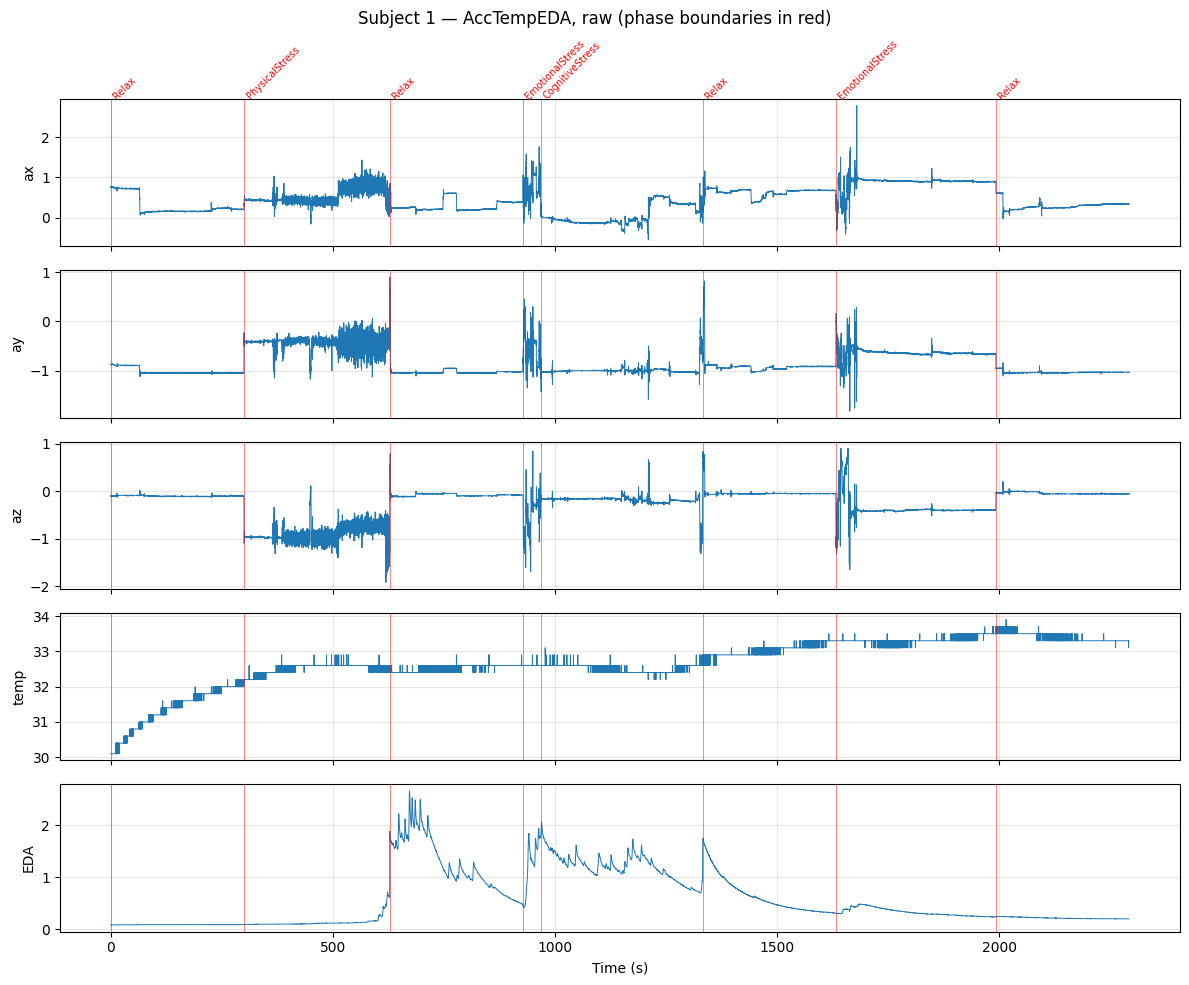

In [3]:
def plot_channels(record, title):
    signal, names, fs = record['signal'], record['signal_names'], record['sampling_frequency']
    time = np.arange(len(signal)) / fs
    phase_times = [s / fs for s in record['annotation_samples']]
    phase_labels = record['annotation_labels']

    fig, axes = plt.subplots(len(names), 1, figsize=(12, 2 * len(names)), sharex=True)
    for i, ax in enumerate(axes):
        ax.plot(time, signal[:, i], lw=0.7)
        ax.set_ylabel(names[i])
        for t, label in zip(phase_times, phase_labels):
            ax.axvline(t, color='red', lw=0.7, alpha=0.5)
            if i == 0:
                ax.text(t + 1, ax.get_ylim()[1], label, fontsize=7, color='red', rotation=45)
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_channels(record_eda, 'Subject 1 — AccTempEDA, raw (phase boundaries in red)')

### What each channel physiologically represents

- **Acc (accelerometer)** — body movement. Clean, almost binary: elevated only during PhysicalStress, flat everywhere else. Good discriminator for *physical* activity, not mental stress.
- **EDA (electrodermal activity)** — skin conductance, driven purely by the sympathetic ("fight or flight") nervous system. The most direct stress marker available: responds to *both* physical and mental stress, with a sharp rise and a slow (minutes-long) decay afterward.
- **Temp (skin temperature)** — responds slowly (minutes). In this dataset it drifts upward across the *entire* session regardless of phase (most likely the wrist warming up under the sensor) — not obviously phase-locked from a first look.
- **HR (heart rate)** — rises with both physical exertion and mental stress, recovers during rest. Solid secondary signal, complements EDA.
- **SpO2 (blood oxygen saturation)** — tightly regulated in healthy people (stays ~97–99%). No strong a-priori reason to expect it to track psychological stress.

The accelerometer channels here are sampled at 8 Hz (not the Empatica E4's native 32 Hz) — the WFDB record stores all 5 `AccTempEDA` channels at one shared rate, so accelerometry was downsampled to match EDA/temp before being written to disk. That puts the accelerometer's Nyquist frequency at 4 Hz, not 16 Hz — relevant later for the frequency-domain features.

## 2. Preprocessing

Two steps, applied per subject, per record:

1. **Zero-phase low-pass Butterworth filter** (order 4, `filtfilt` — forward+backward so the filter doesn't shift the signal in time, which matters since we care about exact timing relative to phase boundaries).
2. **Per-subject Z-score normalization**, with mean/std computed over the **entire recording, before segmentation** — computing stats per-phase instead would leak each phase's own boundary into its own normalization. This also puts every subject on a comparable scale despite very different individual baselines (resting HR, resting EDA level, etc.): every `_mean` feature reported later is "how far above *this subject's own* session average," not an absolute physical unit.

**Filter cutoff choice is governed by Nyquist headroom**, not one fixed value everywhere: a low-pass filter is only safe to use before spectral analysis if its cutoff sits *above* every frequency the analysis actually cares about — otherwise it removes the very thing being measured. Acc's movement band (0.5–4 Hz) already reaches this record's 4 Hz Nyquist ceiling, and HR/SpO2's band already reaches 0.4 Hz of a 0.5 Hz Nyquist — neither has room for a cutoff that wouldn't cut into the band itself, so **both are left unfiltered for the feature-extraction pipeline**. EDA/temp's bands top out at 0.25 Hz, leaving real headroom up to 4 Hz, so they get a 1.0 Hz cutoff.

Note on the plot below: EDA's own physiological content already lives well under the 1.0 Hz cutoff, so the filter is *supposed* to leave the signal's shape almost untouched — it's only meant to strip a thin sliver of high-frequency sensor noise above that. A raw-vs-filtered overlay for EDA is expected to look like near-total overlap; the actual removed content is shown separately below.

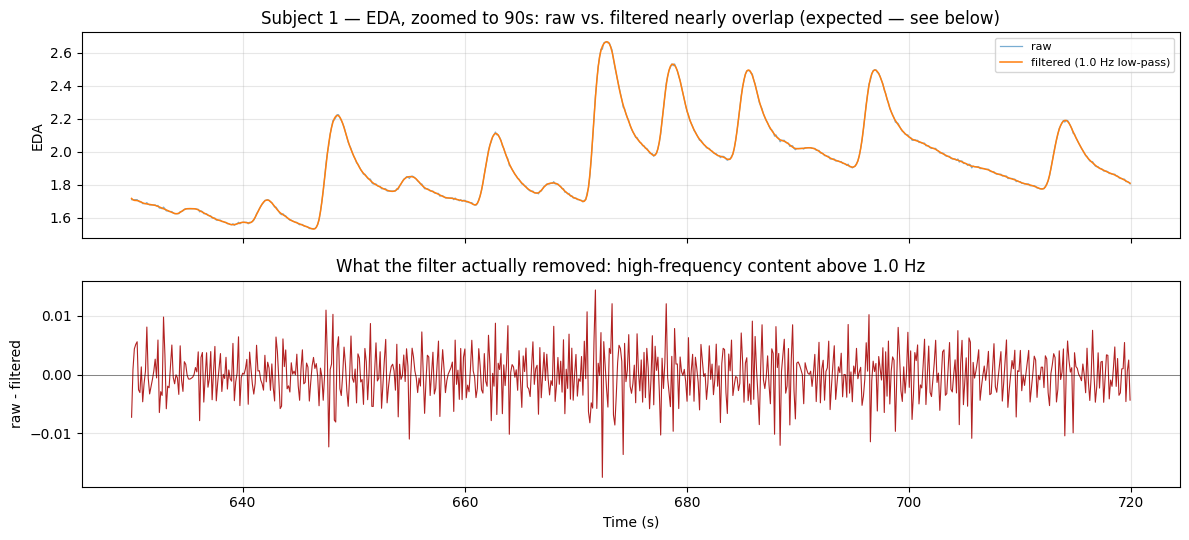


Per-channel mean/std, AccTempEDA — raw vs. after filter+normalize:
  ax     raw: mean=   0.434 std=  0.319   normalized: mean=  0.00000 std= 1.00000
  ay     raw: mean=  -0.853 std=  0.247   normalized: mean=  0.00000 std= 1.00000
  az     raw: mean=  -0.260 std=  0.311   normalized: mean=  0.00000 std= 1.00000
  temp   raw: mean=  32.677 std=  0.666   normalized: mean=  0.00000 std= 1.00000
  EDA    raw: mean=   0.571 std=  0.535   normalized: mean= -0.00000 std= 1.00000


In [4]:
eda_idx = record_eda['signal_names'].index('EDA')
fs = record_eda['sampling_frequency']
eda_raw_full = record_eda['signal'][:, eda_idx]
eda_filtered_full = filter_signal(record_eda['signal'], sampling_frequency=fs, cutoff=1.0)[:, eda_idx]
eda_residual_full = eda_raw_full - eda_filtered_full

window_start, window_end = 630, 720
start_sample, end_sample = int(window_start * fs), int(window_end * fs)
time_window = np.arange(start_sample, end_sample) / fs
eda_raw_window = eda_raw_full[start_sample:end_sample]
eda_filtered_window = eda_filtered_full[start_sample:end_sample]
eda_residual_window = eda_residual_full[start_sample:end_sample]

fig, (ax_signal, ax_residual) = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
ax_signal.plot(time_window, eda_raw_window, lw=0.9, alpha=0.6, label='raw')
ax_signal.plot(time_window, eda_filtered_window, lw=1.1, label='filtered (1.0 Hz low-pass)')
ax_signal.set_ylabel('EDA')
ax_signal.set_title('Subject 1 — EDA, zoomed to 90s: raw vs. filtered nearly overlap (expected — see below)')
ax_signal.legend(loc='upper right', fontsize=8)
ax_signal.grid(alpha=0.3)

ax_residual.plot(time_window, eda_residual_window, lw=0.8, color='firebrick')
ax_residual.axhline(0, color='black', lw=0.6, alpha=0.5)
ax_residual.set_ylabel('raw - filtered')
ax_residual.set_xlabel('Time (s)')
ax_residual.set_title('What the filter actually removed: high-frequency content above 1.0 Hz')
ax_residual.grid(alpha=0.3)

plt.tight_layout()
plt.show()

residual_pct_window = eda_residual_window.std() / eda_raw_window.std() * 100
residual_pct_full = eda_residual_full.std() / eda_raw_full.std() * 100

record_acc, record_hr_proc = load_and_preprocess_subject(1, accel_cutoff=None, eda_temp_cutoff=1.0, spo2_hr_cutoff=None)

print("\nPer-channel mean/std, AccTempEDA — raw vs. after filter+normalize:")
for i, ch in enumerate(record_eda['signal_names']):
    before = record_eda['signal'][:, i]
    after = record_acc['signal'][:, i]
    print(f"  {ch:<6} raw: mean={before.mean():8.3f} std={before.std():7.3f}   normalized: mean={after.mean():9.5f} std={after.std():8.5f}")

## 3. Windowing strategy

Features are computed on **fixed 60-second windows with a 30-second step (50% overlap), sliced within each phase** (never crossing a phase boundary) — not on one spectrum per whole phase. Three reasons:

1. **Dataset size** — one row per phase gives only ~140 rows (7 phases × 20 subjects), too little for a meaningful train/test split.
2. **Non-stationarity** — EDA in particular spikes then decays exponentially *within* a phase; a single spectrum over 5–6 minutes would average "just spiked" and "recovering" into one blurred estimate.
3. **Variable-length phases** — phases run 40 s–6.5 min; a tabular classifier needs uniform feature columns per row.

This also gives a free, principled way to drop the ~40 s anticipation-only EmotionalStress phase: it's shorter than one window, so it simply yields zero windows — no manual label filtering needed.

In [5]:
windows_acc = get_phase_windows(record_acc, WINDOW_SECONDS, STEP_SECONDS)
counts = Counter(w['label'] for w in windows_acc)
print(f"Subject 1: {len(windows_acc)} windows total, per phase: {dict(counts)}")
print("(the ~40s mini EmotionalStress phase contributes 0 windows here — auto-dropped, not label-filtered)")

Subject 1: 67 windows total, per phase: {'Relax': 36, 'PhysicalStress': 9, 'CognitiveStress': 11, 'EmotionalStress': 11}
(the ~40s mini EmotionalStress phase contributes 0 windows here — auto-dropped, not label-filtered)


## 4. Frequency-domain features — the project's key technical contribution

Spectral features are computed via **Welch's method**: the signal is split into overlapping sub-segments, a periodogram is computed for each, and the results are averaged. Averaging reduces the variance of the spectral estimate relative to a single raw FFT, at the cost of **frequency resolution** (`1 / segment length in seconds`) — shorter sub-segments average more but blur nearby frequencies together. This resolution-vs-variance tradeoff dictates the per-signal Welch settings below: narrow, literature-defined physiological bands require long, unaveraged segments to remain resolvable at all, while wider bands can be averaged for noise reduction without losing bandwidth.

| Signal | Method | Why |
|---|---|---|
| HR (1 Hz) | Single-segment Welch, whole 60s window | Only 60 samples — sub-averaging would worsen the resolution needed for the LF band (0.04–0.15 Hz) |
| EDA (8 Hz) | Single-segment Welch, whole 60s window | Literature bands are only 0.03–0.1 Hz wide — averaged sub-segments left some bands with 0–1 usable frequency bins |
| Acc magnitude (8 Hz) | Averaged Welch, 16s sub-segments | Movement band (0.5–4 Hz) is wide enough that averaging denoises the gait peak without losing the band |
| Temp / SpO2 | Averaged Welch / single-segment | Generic descriptors only — not expected a priori to carry strong band-specific content |

**Universal features** (every channel): `total_power`, `dominant_frequency`, `spectral_entropy`. **Band-specific:** HR gets `lf_power`/`hf_power`/`lf_hf_ratio` (sympathovagal balance); EDA gets `tonic`/`sympathetic_low`/`sympathetic_high` power (Posada-Quintero et al. 2016 bands); Acc gets `postural`/`movement` power and a gait-cadence `dominant_frequency`.

A **spectrogram** (below) shows *when* spectral content appears, not just whether — used here only to illustrate the idea; the actual tabular features use one Welch spectrum per 60s window, not a full 2D spectrogram.

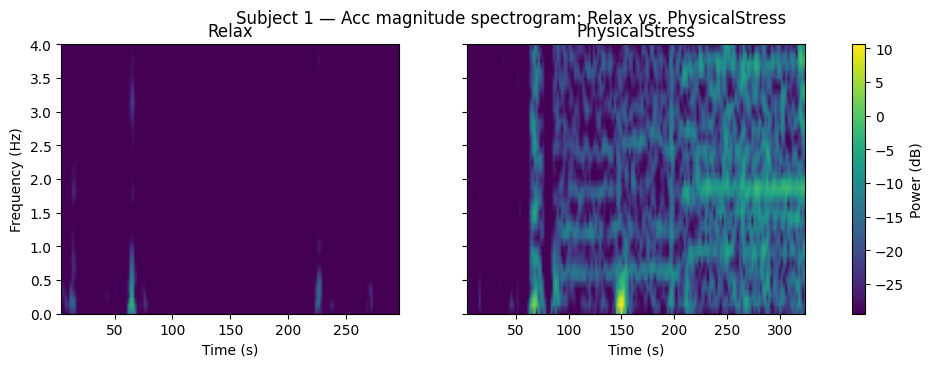

In [6]:
def plot_spectrogram_pair(signal_a, signal_b, label_a, label_b, fs, title, dynamic_range_db=40):
    nperseg, noverlap = 64, 48
    freqs_a, times_a, sxx_a = compute_spectrogram(signal_a, fs, nperseg, noverlap)
    freqs_b, times_b, sxx_b = compute_spectrogram(signal_b, fs, nperseg, noverlap)

    epsilon = 1e-12
    sxx_a_db, sxx_b_db = 10 * np.log10(sxx_a + epsilon), 10 * np.log10(sxx_b + epsilon)
    vmax = max(sxx_a_db.max(), sxx_b_db.max())
    vmin = vmax - dynamic_range_db

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
    mesh = None
    for ax, freqs, times, sxx_db, label in [
        (axes[0], freqs_a, times_a, sxx_a_db, label_a), (axes[1], freqs_b, times_b, sxx_b_db, label_b),
    ]:
        mesh = ax.pcolormesh(times, freqs, sxx_db, shading='gouraud', vmin=vmin, vmax=vmax, cmap='viridis')
        ax.set_title(label)
        ax.set_xlabel('Time (s)')
    axes[0].set_ylabel('Frequency (Hz)')
    fig.colorbar(mesh, ax=axes, label='Power (dB)')
    fig.suptitle(title)
    plt.show()

segments = get_phase_segments(record_acc)
names = record_acc['signal_names']
relax_acc_magnitude = compute_acc_magnitude(segments[0]['signal'], names)
physical_acc_magnitude = compute_acc_magnitude(segments[1]['signal'], names)
plot_spectrogram_pair(
    relax_acc_magnitude, physical_acc_magnitude, 'Relax', 'PhysicalStress', record_acc['sampling_frequency'],
    'Subject 1 — Acc magnitude spectrogram: Relax vs. PhysicalStress'
)

In [7]:
frequency_rows = []
for subject_id in range(1, 21):
    r_acc, r_hr = load_and_preprocess_subject(subject_id, accel_cutoff=None, eda_temp_cutoff=1.0, spo2_hr_cutoff=None)
    rows = assemble_subject_rows(r_acc, r_hr, WINDOW_SECONDS, STEP_SECONDS, extract_window_features)
    for row in rows:
        row['subject_id'] = subject_id
    frequency_rows.extend(rows)

frequency_features_df = pd.DataFrame(frequency_rows)
print(f"Frequency-domain features: {frequency_features_df.shape[0]} windows x {frequency_features_df.shape[1]} columns, "
      f"{frequency_features_df['subject_id'].nunique()} subjects")

# Sanity check: do these features separate Relax from stress phases at all?
frequency_features_df.groupby('label')[['eda_sympathetic_low_power', 'hr_lf_hf_ratio', 'acc_movement_power']].mean()

Frequency-domain features: 1313 windows x 29 columns, 20 subjects


,eda_sympathetic_low_power,hr_lf_hf_ratio,acc_movement_power
label,,,
CognitiveStress,0.010268,12.253053,0.025434
EmotionalStress,0.000550,12.060949,0.034224
PhysicalStress,0.001311,10.042535,0.081139
Relax,0.000792,10.501381,0.003809


## 5. Data quality

Two checks: missing values (none found), and construction-derived sanity bounds (power/entropy/ratio columns must be non-negative; `*_dominant_frequency` columns must fall within their channel's Nyquist frequency, per `src/features.py`). A violation here is numerical noise on an otherwise-legitimate window, not a reason to discard it, so these get **clipped** to their valid bound rather than dropped.

In [8]:
from src.data_quality import audit_features, clean_features

FREQ_METADATA_COLUMNS = ['window_index', 'label', 'start_time', 'subject_id']
FREQ_FEATURE_COLUMNS = [c for c in frequency_features_df.columns if c not in FREQ_METADATA_COLUMNS]

report = audit_features(frequency_features_df, FREQ_FEATURE_COLUMNS)
print("Missing values (NaN/Inf):", int(report[['n_nan', 'n_inf']].sum().sum()))
print("Sanity-bound violations (clipped, not dropped):", int(report['n_violations'].sum()))

frequency_features_df = clean_features(frequency_features_df, FREQ_FEATURE_COLUMNS)

Missing values (NaN/Inf): 0
Sanity-bound violations (clipped, not dropped): 118


## 6. Statistical & temporal features

Complements the spectral features with plain time-domain descriptors, on the **same 60s/30s windows**, applied uniformly to all five signals: `mean`, `std`, `skewness` (is there a spike riding a flat baseline, or symmetric spread), and `slope` (least-squares fit against time — is the signal rising or falling *right now*, a direct stress marker a spectrum doesn't state as plainly). Unlike the frequency features, these are plain statistics with no resolution-vs-sample-count tradeoff, so there's no reason to customize them per signal.

The two feature sets are merged on `(subject_id, window_index)` into one table — `window_index` (0-based position in a subject's window sequence) is used rather than `start_time`, which resets to 0 within every phase occurrence (e.g. `Relax` recurs 4 times per subject).

In [9]:
stat_rows = []
for subject_id in range(1, 21):
    r_acc, r_hr = load_and_preprocess_subject(subject_id, accel_cutoff=None, eda_temp_cutoff=1.0, spo2_hr_cutoff=None)
    rows = assemble_subject_rows(r_acc, r_hr, WINDOW_SECONDS, STEP_SECONDS, extract_window_statistical_features)
    for row in rows:
        row['subject_id'] = subject_id
    stat_rows.extend(rows)

statistical_features_df = pd.DataFrame(stat_rows)

combined_features_df = frequency_features_df.merge(
    statistical_features_df.drop(columns=['label', 'start_time']),
    on=['subject_id', 'window_index'], how='inner', validate='one_to_one',
)
print(f"frequency_features : {frequency_features_df.shape}")
print(f"statistical_features: {statistical_features_df.shape}")
print(f"combined_features   : {combined_features_df.shape}")

frequency_features : (1313, 29)
statistical_features: (1313, 24)
combined_features   : (1313, 49)


## 7. Modeling

Five classifiers, spanning simple/interpretable to high-capacity, each in a `StandardScaler` + classifier pipeline:

| Decision | Choice | Why |
|---|---|---|
| Models | Logistic Regression, k-NN, SVM (RBF), Random Forest, Gradient Boosting | Standard spread for a physiological-signal classification baseline comparison |
| Evaluation | 5-fold `StratifiedGroupKFold`, grouped by `subject_id` | Windows overlap (50%) and share a per-subject baseline — a subject's windows must never span train and test, or the model could partly "cheat" by recognizing that subject rather than learning generalizable stress patterns |
| Primary metric | Macro-averaged F1 | Relax is ~54% of the data; a model that always predicts Relax would still score ~54% accuracy while being useless |
| Class imbalance | `class_weight='balanced'` (all but k-NN, which has no such parameter) | Counteracts the Relax-heavy imbalance at training time, complementing macro-F1 at evaluation time |

Every window gets exactly one out-of-fold prediction, from a fold that never saw that window's subject during training — all metrics below are computed on those.

In [10]:
METADATA_COLUMNS = ['window_index', 'label', 'start_time', 'subject_id']
FEATURE_COLUMNS = [c for c in combined_features_df.columns if c not in METADATA_COLUMNS]

X = combined_features_df[FEATURE_COLUMNS]
y = combined_features_df['label']
groups = combined_features_df['subject_id']

MODELS = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'k-Nearest Neighbors': Pipeline([
        ('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=5))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()), ('clf', HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_STATE))
    ]),
}

def run_cv(X, y, groups, models, random_state=RANDOM_STATE):
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_state)
    results = {}
    for name, pipeline in models.items():
        oof_predictions = pd.Series(index=X.index, dtype=object)
        fold_macro_f1 = []
        for train_idx, test_idx in cv.split(X, y, groups):
            pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
            predictions = pipeline.predict(X.iloc[test_idx])
            oof_predictions.iloc[test_idx] = predictions
            fold_macro_f1.append(f1_score(y.iloc[test_idx], predictions, labels=CLASS_ORDER, average='macro'))
        results[name] = {
            'oof_predictions': oof_predictions,
            'fold_macro_f1_mean': float(np.mean(fold_macro_f1)),
            'fold_macro_f1_std': float(np.std(fold_macro_f1)),
            'oof_macro_f1': f1_score(y, oof_predictions, labels=CLASS_ORDER, average='macro'),
            'oof_accuracy': accuracy_score(y, oof_predictions),
        }
    return results

results = run_cv(X, y, groups, MODELS)

summary_df = pd.DataFrame([
    {'model': name, 'fold_macro_f1_mean': r['fold_macro_f1_mean'], 'fold_macro_f1_std': r['fold_macro_f1_std'],
     'oof_macro_f1': r['oof_macro_f1'], 'oof_accuracy': r['oof_accuracy']}
    for name, r in results.items()
]).sort_values('oof_macro_f1', ascending=False).reset_index(drop=True)
summary_df

,model,fold_macro_f1_mean,fold_macro_f1_std,oof_macro_f1,oof_accuracy
0,Random Forest,0.761143,0.083297,0.768000,0.785986
1,Gradient Boosting,0.749615,0.071079,0.759455,0.785225
2,Logistic Regression,0.729159,0.066286,0.731172,0.730388
3,SVM (RBF),0.723579,0.076902,0.727192,0.723534
4,k-Nearest Neighbors,0.640034,0.063134,0.642194,0.682407


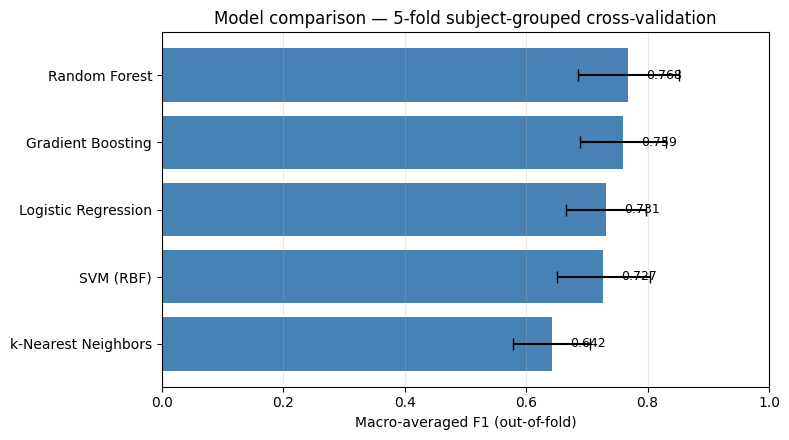

Best model: Random Forest

                 precision    recall  f1-score   support

          Relax      0.844     0.824     0.834       709
 PhysicalStress      0.940     0.961     0.951       180
CognitiveStress      0.728     0.746     0.737       201
EmotionalStress      0.541     0.561     0.551       223

       accuracy                          0.786      1313
      macro avg      0.763     0.773     0.768      1313
   weighted avg      0.788     0.786     0.787      1313



In [11]:
plot_df = summary_df.sort_values('oof_macro_f1')
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(plot_df['model'], plot_df['oof_macro_f1'], xerr=plot_df['fold_macro_f1_std'], color='steelblue', capsize=4)
ax.set_xlabel('Macro-averaged F1 (out-of-fold)')
ax.set_xlim(0, 1)
ax.set_title('Model comparison — 5-fold subject-grouped cross-validation')
ax.grid(axis='x', alpha=0.3)
for bar, value in zip(bars, plot_df['oof_macro_f1']):
    ax.text(min(value + 0.03, 0.97), bar.get_y() + bar.get_height() / 2, f'{value:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

best_model_name = summary_df.iloc[0]['model']
print(f"Best model: {best_model_name}\n")
print(classification_report(y, results[best_model_name]['oof_predictions'], labels=CLASS_ORDER, digits=3))

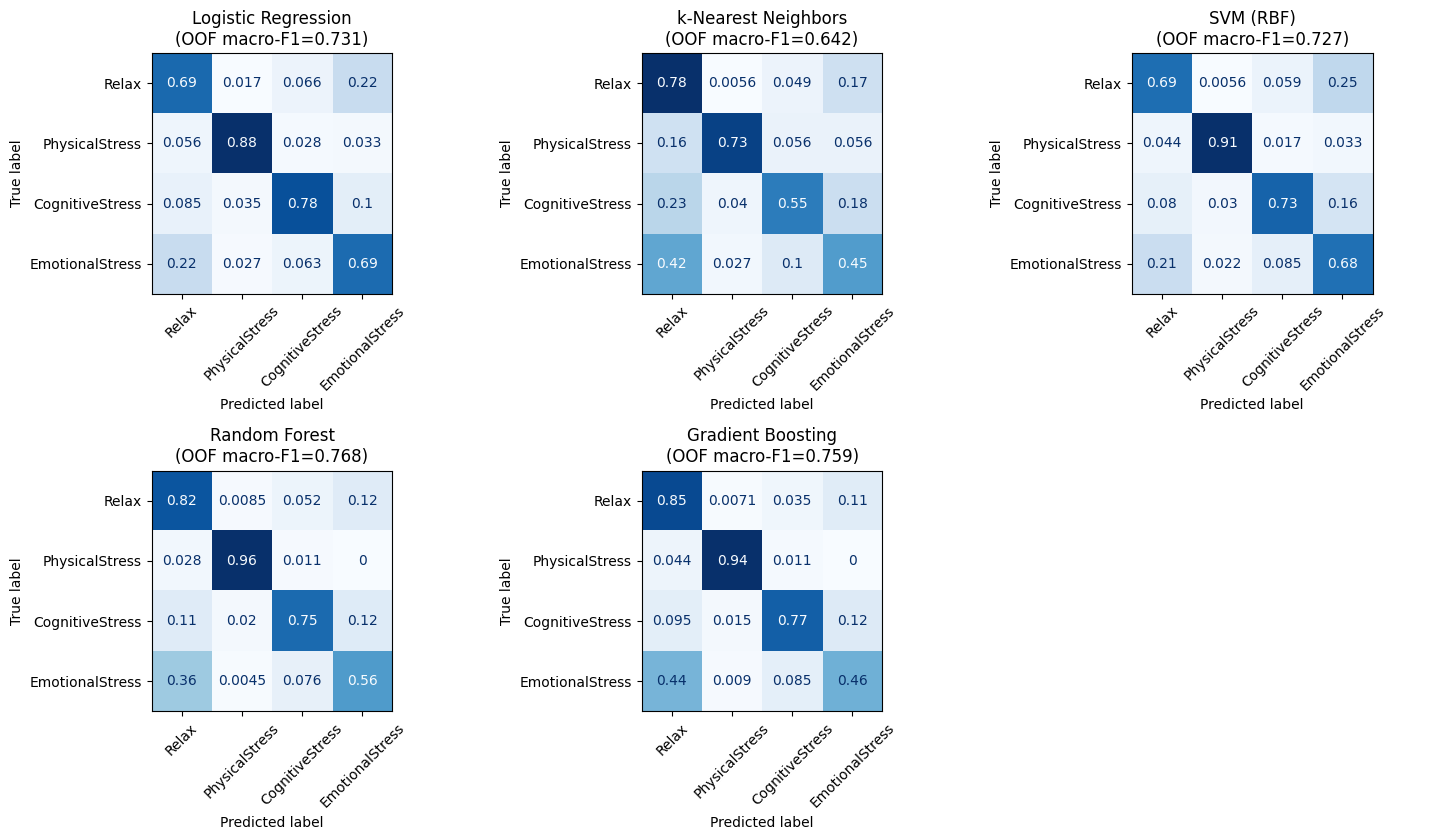

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
axes = axes.ravel()
for ax, (model_name, r) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y, r['oof_predictions'], labels=CLASS_ORDER, normalize='true', cmap='Blues',
        ax=ax, colorbar=False, xticks_rotation=45,
    )
    ax.set_title(f"{model_name}\n(OOF macro-F1={r['oof_macro_f1']:.3f})")
for ax in axes[len(results):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 8. Feature importance — and a confound worth taking seriously

Section 1 expected Temp and SpO2 to be poor stress markers (Temp drifts with time regardless of phase; SpO2 is tightly homeostatically regulated). Feature importance says otherwise — worth checking *why* rather than trusting a top-ranked feature at face value, since Random Forest's built-in impurity-based importance is known to be biased toward continuous features (exactly what `temp_mean` is). `sklearn.inspection.permutation_importance` (shuffle a feature, measure the score drop) is a more trustworthy alternative, used below alongside a direct correlation check and an ablation re-run.

In [13]:
importance_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE)),
])
importance_pipeline.fit(X, y)

permutation_result = permutation_importance(
    importance_pipeline, X, y, n_repeats=15, random_state=RANDOM_STATE, scoring='f1_macro', n_jobs=-1
)
permutation_df = pd.DataFrame({
    'feature': FEATURE_COLUMNS, 'permutation_importance': permutation_result.importances_mean,
}).sort_values('permutation_importance', ascending=False).reset_index(drop=True)
permutation_df['rank'] = permutation_df.index + 1

print("Top 10 features by permutation importance:")
print(permutation_df[['rank', 'feature', 'permutation_importance']].head(10).to_string(index=False))

temp_window_corr = combined_features_df['temp_mean'].corr(combined_features_df['window_index'])
print(f"\ntemp_mean vs. window_index correlation: {temp_window_corr:.3f}")
print("(every subject follows the same fixed phase order, and temp drifts monotonically upward across the "
      "whole session — so temp_mean is partly acting as a proxy for elapsed session time, not a genuine "
      "phase-specific response)")

Top 10 features by permutation importance:
 rank             feature  permutation_importance
    1            eda_mean                0.034987
    2             hr_mean                0.031048
    3           temp_mean                0.028752
    4           spo2_mean                0.005801
    5           eda_slope                0.004663
    6          temp_slope                0.003085
    7 hr_spectral_entropy                0.002480
    8        acc_skewness                0.002201
    9           acc_slope                0.002198
   10              hr_std                0.002168

temp_mean vs. window_index correlation: 0.755
(every subject follows the same fixed phase order, and temp drifts monotonically upward across the whole session — so temp_mean is partly acting as a proxy for elapsed session time, not a genuine phase-specific response)


In [14]:
# Re-run the same 5-fold comparison with all temp_*/spo2_* features excluded, to see how much of the
# reported score depends on the session-position shortcut identified above.
no_confound_columns = [c for c in FEATURE_COLUMNS if not (c.startswith('temp_') or c.startswith('spo2_'))]
X_no_confound = combined_features_df[no_confound_columns]

results_no_confound = run_cv(X_no_confound, y, groups, MODELS)

print(f"{'Model':22s} {'macro-F1 (45 feat)':>20s} {'macro-F1 (31 feat)':>20s} {'Delta':>8s}")
print('-' * 74)
for model_name in MODELS:
    baseline = results[model_name]['oof_macro_f1']
    no_confound = results_no_confound[model_name]['oof_macro_f1']
    print(f"{model_name:22s} {baseline:>20.3f} {no_confound:>20.3f} {no_confound - baseline:>8.3f}")

print(f"\nBest model ({best_model_name}) per-class, temp_*/spo2_* excluded:")
print(classification_report(y, results_no_confound[best_model_name]['oof_predictions'], labels=CLASS_ORDER, digits=3))

Model                    macro-F1 (45 feat)   macro-F1 (31 feat)    Delta
--------------------------------------------------------------------------
Logistic Regression                   0.731                0.692   -0.039
k-Nearest Neighbors                   0.642                0.640   -0.002
SVM (RBF)                             0.727                0.689   -0.038
Random Forest                         0.768                0.745   -0.023
Gradient Boosting                     0.759                0.732   -0.027

Best model (Random Forest) per-class, temp_*/spo2_* excluded:
                 precision    recall  f1-score   support

          Relax      0.844     0.786     0.814       709
 PhysicalStress      0.902     0.922     0.912       180
CognitiveStress      0.716     0.751     0.733       201
EmotionalStress      0.484     0.561     0.520       223

       accuracy                          0.761      1313
      macro avg      0.737     0.755     0.745      1313
   weighted avg  

**Interpretation.** Dropping `temp_*`/`spo2_*` costs real score for every model except k-NN (which barely used them either way) — this is not negligible, so the original hypothesis that these two channels are useless turns out to be **empirically wrong**. The per-class breakdown shows where the value concentrates: PhysicalStress and EmotionalStress lose the most, while Relax and CognitiveStress barely move. A drop concentrated in PhysicalStress is physiologically plausible on its own terms (transient SpO2 dips and skin-temperature changes under real exertion) — separate from `temp_mean`'s demonstrated session-position confound, which rides along in the same ablation. Distinguishing "genuine exertion-related signal" from "the confound riding along" would need testing each channel in isolation; not done here, left as an open follow-up.

**Bottom line for reporting results:** quote the Random Forest, `temp_*`/`spo2_*`-excluded macro-F1 from the table above (≈0.745) as the trustworthy estimate of real-world performance — it doesn't depend on a shortcut that's an artifact of this protocol's fixed phase ordering. The full-feature number (≈0.768) is real but partly inflated by that shortcut and shouldn't be quoted without this caveat.

## 9. Concluding thoughts

**What worked.** Collapsing each 60s window into ~45 hand-designed spectral and statistical numbers, then handing them to classical classifiers, was the right call at this scale (20 subjects, 1313 windows) — a raw-waveform deep-learning approach would have far too little data to learn a reliable representation from scratch. Random Forest separates PhysicalStress cleanly (F1 ≈ 0.95, matching its almost-binary accelerometer signature) and does reasonably on Relax; EDA, HR, and accelerometer-derived features consistently show up as the most useful predictors, matching what the underlying physiology would predict.

**What was hardest.** EmotionalStress is the weakest class (F1 ≈ 0.55) — consistent with the observed habituation of the EDA/HR response across repeated stressors within a session: by the time a subject reaches the (later-occurring) EmotionalStress phase, their physiological reactivity has already been blunted by the earlier PhysicalStress and CognitiveStress phases, making it the phase that looks least distinct from Relax.

**Methodological note.** Interpretable, hand-engineered features carry a practical advantage over opaque models beyond readability alone: an unexpected result can be traced to its source rather than accepted at face value. `temp_mean`'s high ranking in feature importance warranted investigation rather than acceptance, and was found to originate from an artifact of the study design — the fixed phase order shared by all subjects — rather than genuine physiological signal. The subsequent ablation, however, revealed a larger-than-expected cost to removing it, with the residual effect plausibly attributable to PhysicalStress physiology. This more nuanced conclusion is considerably more informative than either discarding the feature outright or accepting its apparent importance unquestioned.

**Limitations, stated plainly:**
- No hyperparameter tuning — this is a baseline model comparison, not any model's ceiling performance.
- Only 20 subjects; grouped 5-fold CV holds out 4 subjects per fold, so individual fold scores are noisy (the fold mean ± std reported above is the more honest read than any single fold).
- HR/SpO2 spectral analysis is "ultra-short-term" (60s window, 1 Hz sampling) and computed from the bpm/percentage series directly — not a canonical RR-interval tachogram or the standard 5-minute HRV window.
- The ~40s anticipation-only EmotionalStress phase is excluded from the feature set entirely, since it can't support even one analysis window.
- The Temp/SpO2 confound-vs-genuine-signal question is only partially resolved (see Section 8) — isolating the two effects would need a follow-up ablation testing each channel independently.

**Where to look for more detail.** `01_exploration.ipynb` through `05_modeling.ipynb` (in this same folder) contain the full derivations, verification steps (e.g. confirming the mini-EmotionalStress auto-drop across all 20 subjects), and the dead ends that shaped these decisions (e.g. the EDA windowing resolution initially chosen incorrectly, caught by a zero-valued feature during verification). `thesis_notes.md` and `concepts_guide.md` (repo root) hold additional reference detail on the dataset, signal processing formulas, and the reasoning behind each design choice.